In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
import kagglehub

In [4]:
path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")

100%|██████████| 3.76k/3.76k [00:00<00:00, 5.34MB/s]

Extracting files...


In [5]:

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/vijayaadithyanvg/car-price-predictionused-cars/versions/1


In [6]:
print(os.listdir(path))

['car data.csv']


In [7]:
df = pd.read_csv(path + "/car data.csv")

In [8]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
df.shape

(301, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
df.columns


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [12]:
df['Car_Name'].value_counts()

,count
Car_Name,
city,26
corolla altis,16
verna,14
fortuner,11
brio,10
...,...
Honda Activa 125,1
Hero Hunk,1
Hero Ignitor Disc,1


In [13]:
df['Fuel_Type'].nunique()

3

In [14]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [15]:
df['Car_Name'].nunique()

98

In [16]:
df['Car_Name'].value_counts()

,count
Car_Name,
city,26
corolla altis,16
verna,14
fortuner,11
brio,10
...,...
Honda Activa 125,1
Hero Hunk,1
Hero Ignitor Disc,1


In [17]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [18]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [19]:
df.duplicated().sum()

np.int64(2)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.shape

(299, 9)

In [22]:
df.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Driven_kms,int64
Fuel_Type,object
Selling_type,object
Transmission,object
Owner,int64


In [23]:
df.nunique()

,0
Car_Name,98
Year,16
Selling_Price,156
Present_Price,148
Driven_kms,206
Fuel_Type,3
Selling_type,2
Transmission,2
Owner,3


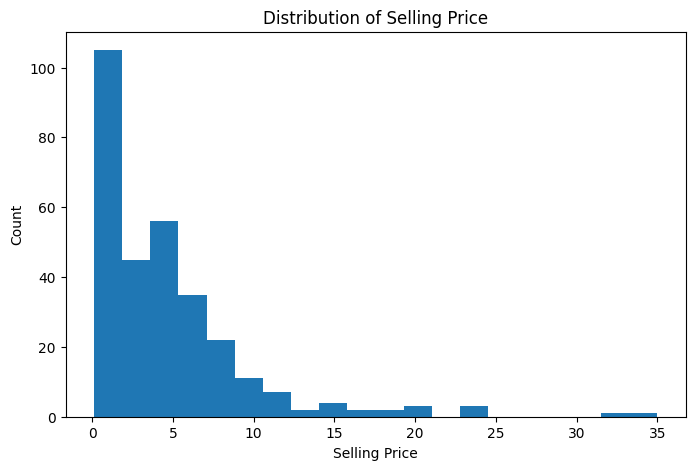

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df['Selling_Price'], bins=20)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()

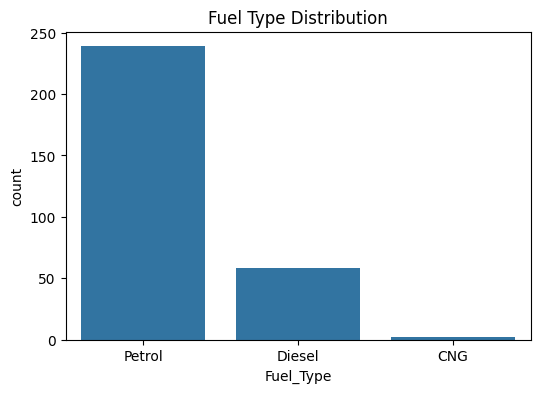

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Fuel_Type')
plt.title("Fuel Type Distribution")
plt.show()

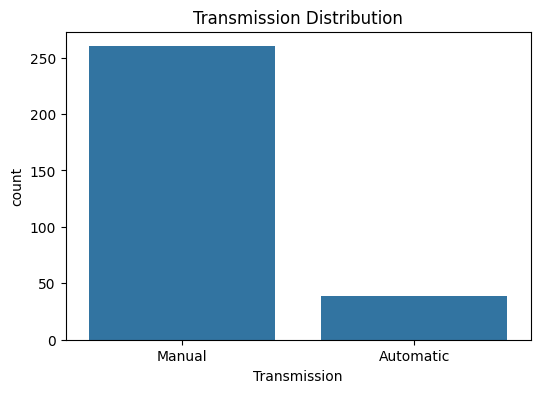

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Transmission')
plt.title("Transmission Distribution")
plt.show()

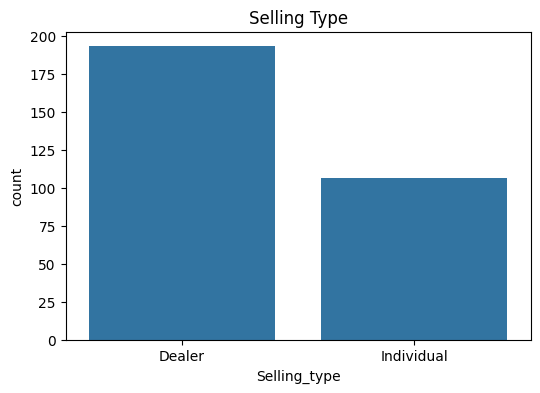

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Selling_type')
plt.title("Selling Type")
plt.show()

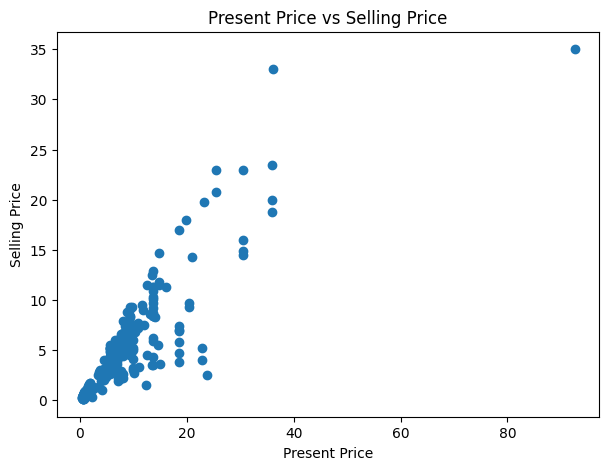

In [28]:
plt.figure(figsize=(7,5))

plt.scatter(df['Present_Price'], df['Selling_Price'],)
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")
plt.show()

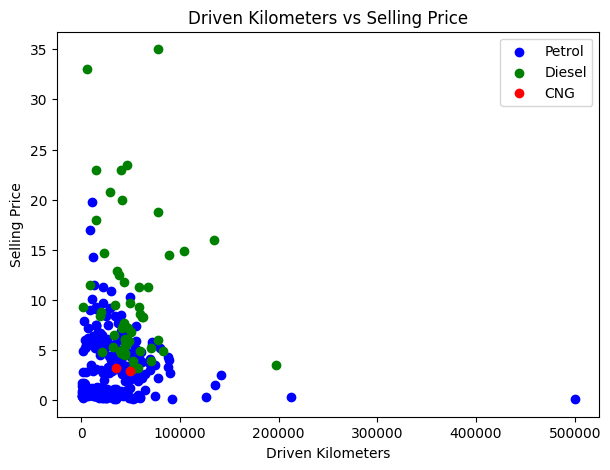

In [29]:
plt.figure(figsize=(7,5))

colors = {
    'Petrol': 'blue',
    'Diesel': 'green',
    'CNG': 'red'
}

for fuel in df['Fuel_Type'].unique():
    subset = df[df['Fuel_Type'] == fuel]
    plt.scatter(subset['Driven_kms'],
                subset['Selling_Price'],
                color=colors[fuel],
                label=fuel)

plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price")
plt.title("Driven Kilometers vs Selling Price")
plt.legend()
plt.show()

In [30]:
numeric_df = df.select_dtypes(include=['number'])

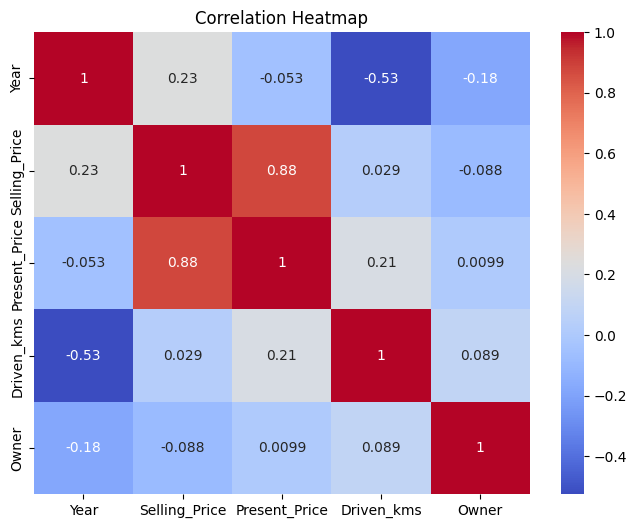

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [32]:
car_df = df.copy()

In [33]:
current_year = 2026
car_df['Car_Age'] = current_year - car_df['Year']

In [34]:
car_df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [35]:
car_df.drop('Year', axis=1, inplace=True)

In [36]:
car_df['Brand'] = car_df['Car_Name'].str.split().str[0]

In [37]:
car_df[['Car_Name', 'Brand']].head()

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


In [38]:
car_df.drop('Car_Name', axis=1, inplace=True)

In [39]:
car_df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift


In [40]:
car_df.select_dtypes(include='object').columns

Index(['Fuel_Type', 'Selling_type', 'Transmission', 'Brand'], dtype='object')

In [41]:
car_df = pd.get_dummies(car_df, drop_first=True)

In [42]:
car_df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Brand_Activa,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,3.35,5.59,27000,0,12,False,True,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,13,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,7.25,9.85,6900,0,9,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,15,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,4.60,6.87,42450,0,12,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [53]:
y = car_df['Selling_Price']

X = car_df.drop('Selling_Price', axis=1)

In [55]:
y.shape

(299,)

In [44]:
from sklearn.model_selection import train_test_split


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
from sklearn.linear_model import LinearRegression
model_lr=LinearRegression()

In [47]:
model_lr.fit(X_train,y_train)

LinearRegression()

In [56]:
y_test.shape


(60,)

In [71]:
y_pred_lr=model_lr.predict(X_test)
y_pred_lr.shape

(60,)

In [58]:
model_lr.score(X_test,y_test)

0.5526191096181184

In [72]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_lr)
print("R² Score:", r2)

R² Score: 0.5526191096181184


In [74]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("MSE :", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr) ** 0.5)
print("R²  :", r2_score(y_test, y_pred_lr))

MAE : 1.807786967346579
MSE : 11.530465001023488
RMSE: 3.3956538399877405
R²  : 0.5526191096181184


In [61]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

In [62]:
from sklearn.metrics import r2_score

print("R² Score:", r2_score(y_test, y_pred_dt))

R² Score: 0.6223487381582704


In [88]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [89]:
from sklearn.metrics import r2_score

print("R² Score:", r2_score(y_test, y_pred_rf))

R² Score: 0.6202137057284518


In [90]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(random_state=42)

model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

In [91]:
from sklearn.ensemble import AdaBoostRegressor

model_ab = AdaBoostRegressor(random_state=42)

model_ab.fit(X_train, y_train)

y_pred_ab = model_ab.predict(X_test)

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
from sklearn.svm import SVR

model_svr = SVR()

model_svr.fit(X_train_scaled, y_train)

y_pred_svr = model_svr.predict(X_test_scaled)

In [97]:
from sklearn.metrics import r2_score

print("Linear Regression :", r2_score(y_test, y_pred_lr))
print("Decision Tree     :", r2_score(y_test, y_pred_dt))
print("Random Forest     :", r2_score(y_test, y_pred_rf))
print("Gradient Boosting :", r2_score(y_test, y_pred_gb))
print("AdaBoost          :", r2_score(y_test, y_pred_ab))
print("SVR               :", r2_score(y_test, y_pred_svr))

Linear Regression : 0.5526191096181184
Decision Tree     : 0.6223487381582704
Random Forest     : 0.6202137057284518
Gradient Boosting : 0.7041831008301865
AdaBoost          : 0.6109249756391824
SVR               : 0.5394214744623242


In [98]:
# From above scores we can say best model for this dataset is Graidient Boosting
# if we used cross validation and hyperparameter tuning then we can increase the r2_score